In [8]:
import pandas as pd

df = pd.read_csv("Processed_Reviews.csv")

In [9]:
print(df.head())

                                              Review  \
0  The product arrived on time. Packaging was gre...   
1           THIS PRODUCT IS JUST AMAZING! I LOVE IT.   
2  I bought this phone for $799, and it has a 120...   
3  Wow!!! This product is awesome... but a bit ex...   
4                The laptop works perfectly fine.      

                                          lowercased  \
0  the product arrived on time. packaging was gre...   
1           this product is just amazing! i love it.   
2  i bought this phone for $799, and it has a 120...   
3  wow!!! this product is awesome... but a bit ex...   
4                the laptop works perfectly fine.      

                                        urls_removed  \
0  the product arrived on time. packaging was gre...   
1           this product is just amazing! i love it.   
2  i bought this phone for $799, and it has a 120...   
3  wow!!! this product is awesome... but a bit ex...   
4                the laptop works perfectly fi

In [10]:
print(df.columns.tolist())

['Review', 'lowercased', 'urls_removed', 'html_removed', 'emojis_removed', 'slangs_replaced', 'contractions_replaced', 'punctuations_removed', 'numbers_removed', 'spelling_corrected', 'stopwords_removed', 'stemmed_words', 'lemmatized', 'tokenized', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'label']


In [11]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Review', 'lowercased', 'urls_removed', 'html_removed', 'emojis_removed', 'slangs_replaced', 'contractions_replaced', 'punctuations_removed', 'numbers_removed', 'spelling_corrected', 'stopwords_removed', 'stemmed_words', 'lemmatized', 'tokenized', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'label']


In [12]:
X = df['lemmatized']
y = df['label']

In [13]:
print(X.head())
print(y.head())

0    product arrive time packaging great quality am...
1                                   product amaze love
2                   buy phone hz display totally worth
3                    wow product awesome bit expensive
4                           laptop work perfectly fine
Name: lemmatized, dtype: object
0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64


In [14]:
df['label'] = df['label'].map({'positive':1, 'negative':0})

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(X)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [18]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [19]:
nb_pred = nb_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Naive Bayes
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("\nNaive Bayes Report:\n", classification_report(y_test, nb_pred))

nb_cm = confusion_matrix(y_test, nb_pred)

# SVM
print("\nSVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nSVM Report:\n", classification_report(y_test, svm_pred))

svm_cm = confusion_matrix(y_test, svm_pred)

Naive Bayes Accuracy: 1.0

Naive Bayes Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


SVM Accuracy: 1.0

SVM Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


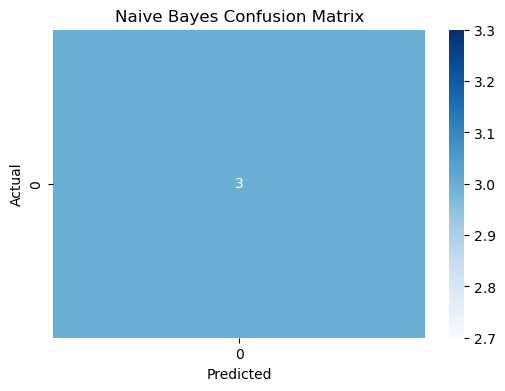

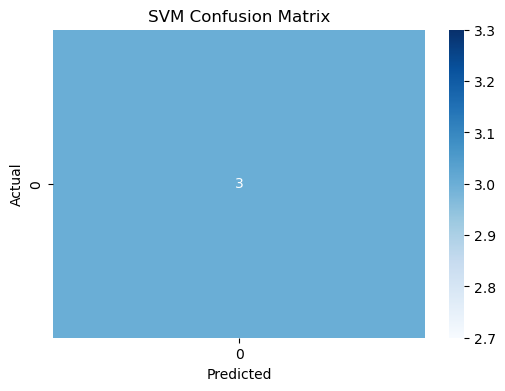

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cm(cm, title):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(nb_cm, "Naive Bayes Confusion Matrix")
plot_cm(svm_cm, "SVM Confusion Matrix")